# Experiment 04 — Controlled Comparison of Local-Scale Additive vs Center-Based Replacement CQR

This notebook implements the **preregistered specification**
`experiments/README_04_controlled_comparison.md` (**v1.1**) exactly. All constants,
formulas, splits, window rules, architecture, training protocol, calibration rule,
methods, metrics, and statistical conventions are frozen by that document and are
restated visibly in the cells below.

**Research question.** Does replacement (center-based) conformal geometry overcome the
interval-width dilution inherent in additive CQR, when the *same* base Quantile LSTM and
the *same* causal local scale estimator are used?

**Design at a glance.**

| Quantity | Frozen value |
|---|---|
| Cycle \(P\) | 96 = 40 low + 8 raised-cosine up + 40 high + 8 raised-cosine down |
| Warm-up | 128 observations discarded as targets; phase not reset |
| D1 | 5,952 targets (54 training + 8 validation cycles) |
| D2 | 2,400 targets (pre-specified diagnostics only; **no** learned-scale arm) |
| D3 | 1,152 targets (conformal calibration) |
| Test | 2,400 targets (final evaluation) |
| Lag / scale window \(L\) | 32, causal, may cross segment boundaries |
| \(\alpha\), rank \(k\) | 0.10; \(k=\lceil 1153\cdot 0.90\rceil = 1038\) |
| Replications | \(R=30\), seeds \(1000+r,\ r=0,\ldots,29\) |
| Architecture | 1-layer LSTM(hidden 32) on scalar lag input; phase concat; `Linear(34, 2)` |
| Training | pinball(0.10, 0.90), Adam \(10^{-3}\), 40 full-batch epochs, no normalization |

**Structure of conclusions.** The *primary* scientific comparison is the paired
difference **Replacement (M3) − Scaled Additive (M2)** across the 30 replications.
*Oracle* methods (using true \(\sigma\)) are labelled diagnostics and never mixed into
the primary comparison. Additional *secondary diagnostics* (ramp regime, D2
out-of-fold checks, scale association) support interpretation only. No theorem-level
iid split-conformal validity is claimed anywhere: the data are dependent time-series
observations, and the chronological protocol is an **empirical time-series evaluation**
(README v1.1, Section 20).

**Hypotheses H1–H5 are empirical** and are not assumed confirmed. Interpretation rules
(README v1.1, Section 25) are enforced: no post-hoc tuning, no use of the oracle/ideal
width-ratio benchmark of 5 as a target, no method selection from test results.


In [1]:
import os

# Execution-environment note (README v1.1, Section 22): this Anaconda environment
# links MKL into NumPy while PyTorch bundles its own libiomp5md.dll. If both OpenMP
# runtimes initialize in one process, the process aborts with "OMP: Error #15".
# Forcing MKL onto its documented sequential threading layer prevents MKL from
# initializing an OpenMP runtime at all; it is NOT the forbidden
# KMP_DUPLICATE_LIB_OK=TRUE workaround and changes no numerical result here
# (no BLAS-dependent computation is used).
os.environ.setdefault("MKL_THREADING_LAYER", "SEQUENTIAL")

import json
import math
import platform
import random
import subprocess
import sys
import time
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# --- repository / output locations -------------------------------------
REPO_ROOT = Path.cwd()
if not ((REPO_ROOT / "experiments").exists() and (REPO_ROOT / "results").exists()):
    REPO_ROOT = REPO_ROOT.parent
RESULTS_DIR = REPO_ROOT / "results" / "experiment_04"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# --- deterministic CPU settings (mirrors Experiment 03; README v1.1 S22) ---
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cpu")

ENVIRONMENT = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "pytorch": torch.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "processor": platform.processor(),
    "device": str(DEVICE),
}
try:
    ENVIRONMENT["git_commit"] = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=REPO_ROOT, text=True).strip()
except Exception:
    ENVIRONMENT["git_commit"] = "unavailable"

warnings.filterwarnings("default")
print(pd.Series(ENVIRONMENT, name="environment").to_string())

python                                                   3.13.5
numpy                                                     2.1.3
pandas                                                    2.2.3
pytorch                                              2.10.0+cpu
matplotlib                                               3.10.0
platform                              Windows-11-10.0.26200-SP0
processor     Intel64 Family 6 Model 154 Stepping 4, Genuine...
device                                                      cpu
git_commit             de21a81e5103caba0a364024193a2bf6619e50b3


## Frozen configuration

Every constant below is fixed by README v1.1 **before** any result is observed.
This dictionary is stored verbatim in the notebook metadata and in
`results/experiment_04/config.json`.

In [2]:
# ================= FROZEN CONFIGURATION (README v1.1) =================
# Data-generating process (Section 4)
P         = 96            # cycle length: 40 low + 8 up + 40 high + 8 down
LOW_SIGMA, HIGH_SIGMA = 0.2, 1.0
N_LOW, N_UP, N_HIGH, N_DOWN = 40, 8, 40, 8
assert N_LOW + N_UP + N_HIGH + N_DOWN == P

# Warm-up and chronological segments (Sections 6-7)
N_WARMUP = 128            # discarded as targets; does NOT reset the phase
SEGMENT_CYCLES = {
    "D1_train": 54,       # gradient updates only
    "D1_val":   8,        # monitored diagnostic; NO early stopping is applied
    "D2":       25,       # pre-specified diagnostics only
    "D3":       12,       # conformal calibration
    "Test":     25,       # final evaluation
}

# Features and scale (Sections 5, 10)
SEQ_LEN = 32              # lag length L and local-scale window length
N_PHASE = 2               # sin/cos target-time phase features
SCALE_DDOF = 0            # frozen standard-deviation convention (v1.1)

# Conformal calibration (Section 8)
ALPHA = 0.10
N_CAL = SEGMENT_CYCLES["D3"] * P                    # 1152
K_CONFORMAL = math.ceil((N_CAL + 1) * (1.0 - ALPHA))  # 1038
assert N_CAL == 1152 and K_CONFORMAL == 1038

# Base model and training (Section 9, frozen v1.1)
HIDDEN_SIZE, NUM_LAYERS = 32, 1
LR, EPOCHS = 1e-3, 40
QUANTILES = (0.10, 0.90)

# Monte Carlo (Section 16)
N_REPS = 30
REPLICATION_SEEDS = [1000 + r for r in range(N_REPS)]   # 1000..1029, 0-based ids

METHOD_NAMES = [
    "M0 Raw Quantile",
    "M1 Standard CQR",
    "M2 Scaled Additive CQR",
    "M3 Replacement CQR",
    "Oracle Additive CQR",
    "Oracle Replacement CQR",
]
ORACLE_METHODS = {"Oracle Additive CQR", "Oracle Replacement CQR"}
ADAPTIVE_METHODS = {"M2 Scaled Additive CQR", "M3 Replacement CQR"}

FROZEN_CONFIG = {
    "spec": "experiments/README_04_controlled_comparison.md (v1.1, preregistered)",
    "P_cycle": P, "plateau_slots": {"low": N_LOW, "up_ramp": N_UP, "high": N_HIGH, "down_ramp": N_DOWN},
    "low_sigma": LOW_SIGMA, "high_sigma": HIGH_SIGMA,
    "transition_profile": "raised cosine at strictly interior fractions m/9, m=1..8",
    "signal": "sin(2*pi*phi) + 0.5*cos(4*pi*phi)",
    "warmup": N_WARMUP, "segments_cycles": SEGMENT_CYCLES,
    "sequence_length": SEQ_LEN, "scale_window": SEQ_LEN, "scale_ddof": SCALE_DDOF,
    "alpha": ALPHA, "n_cal": N_CAL, "k_conformal": K_CONFORMAL,
    "hidden_size": HIDDEN_SIZE, "num_layers": NUM_LAYERS, "lr": LR, "epochs": EPOCHS,
    "quantiles": list(QUANTILES), "optimizer": "Adam", "full_batch": True,
    "input_normalization": "none",
    "architecture": "LSTM(1->32, 1 layer) on lag sequence; phase concat with h_t; Linear(34, 2)",
    "n_replications": N_REPS, "replication_seeds": REPLICATION_SEEDS,
    "seed_rule": "replication_seed = 1000 + replication_id (0-based ids)",
    "boundary_crossing": "target observations define segments; causal lag/scale windows may cross boundaries",
    "regimes": "low=40-slot plateau, high=40-slot plateau, ramp=both 8-slot transitions (mutually exclusive)",
    "headline_regimes": "low and high only; ramp reported separately as diagnostic",
    "width_ratio_benchmark": "oracle/ideal = sigma_H/sigma_L = 5 (NOT a requirement)",
    "winkler": "standard two-sided interval score, alpha=0.10",
    "scale_association": "Spearman(s_t, sigma_t), diagnostic only",
    "paired_ci": "paired t-interval, df=29",
}

print(json.dumps(FROZEN_CONFIG, indent=2))

{
  "spec": "experiments/README_04_controlled_comparison.md (v1.1, preregistered)",
  "P_cycle": 96,
  "plateau_slots": {
    "low": 40,
    "up_ramp": 8,
    "high": 40,
    "down_ramp": 8
  },
  "low_sigma": 0.2,
  "high_sigma": 1.0,
  "transition_profile": "raised cosine at strictly interior fractions m/9, m=1..8",
  "signal": "sin(2*pi*phi) + 0.5*cos(4*pi*phi)",
  "warmup": 128,
  "segments_cycles": {
    "D1_train": 54,
    "D1_val": 8,
    "D2": 25,
    "D3": 12,
    "Test": 25
  },
  "sequence_length": 32,
  "scale_window": 32,
  "scale_ddof": 0,
  "alpha": 0.1,
  "n_cal": 1152,
  "k_conformal": 1038,
  "hidden_size": 32,
  "num_layers": 1,
  "lr": 0.001,
  "epochs": 40,
  "quantiles": [
    0.1,
    0.9
  ],
  "optimizer": "Adam",
  "full_batch": true,
  "input_normalization": "none",
  "architecture": "LSTM(1->32, 1 layer) on lag sequence; phase concat with h_t; Linear(34, 2)",
  "n_replications": 30,
  "replication_seeds": [
    1000,
    1001,
    1002,
    1003,
    1004,
 

## Data-generating process (README v1.1, Section 4)

For global index \(t\) over the entire generated series (including warm-up):

\[
\phi_t = \frac{t \bmod 96}{96}, \qquad
f(\phi) = \sin(2\pi\phi) + 0.5\cos(4\pi\phi), \qquad
y_t = f(\phi_t) + \sigma(\phi_t)\,\epsilon_t,
\]
with \(\epsilon_t \sim \mathcal N(0,1)\) independently across \(t\).

Within each cycle (slot \(j = t \bmod 96\)) the noise scale is, exactly:

| Slots | Regime | \(\sigma\) |
|---|---|---|
| \(j=0\ldots 39\) | low plateau | \(0.2\) |
| \(j=40\ldots 47\) | transition up | \(0.2 + 0.8\,\frac{1-\cos(\pi m/9)}{2},\ m=j-39\) |
| \(j=48\ldots 87\) | high plateau | \(1.0\) |
| \(j=88\ldots 95\) | transition down | \(1.0 - 0.8\,\frac{1-\cos(\pi m/9)}{2},\ m=j-87\) |

Transition slots evaluate the raised cosine at strictly interior fractions
\(m/9\) (\(m=1,\ldots,8\)), so no slot coincides with a plateau value and the
40/8/40/8 counts remain exact. Regime labels are **evaluation-only**.

In [3]:
# --- frozen DGP (README v1.1, Section 4) -------------------------------
def raised_cosine(m):
    # (1 - cos(pi*m/9)) / 2 at strictly interior fractions m = 1..8
    return (1.0 - np.cos(np.pi * np.asarray(m, dtype=float) / 9.0)) / 2.0

SIGMA_CYCLE = np.empty(P)
SIGMA_CYCLE[:N_LOW] = LOW_SIGMA
SIGMA_CYCLE[N_LOW:N_LOW + N_UP] = LOW_SIGMA + (HIGH_SIGMA - LOW_SIGMA) * raised_cosine(np.arange(1, N_UP + 1))
SIGMA_CYCLE[N_LOW + N_UP:N_LOW + N_UP + N_HIGH] = HIGH_SIGMA
SIGMA_CYCLE[N_LOW + N_UP + N_HIGH:] = HIGH_SIGMA - (HIGH_SIGMA - LOW_SIGMA) * raised_cosine(np.arange(1, N_DOWN + 1))

REGIME_LOW, REGIME_RAMP, REGIME_HIGH = 0, 1, 2   # mutually exclusive labels
REGIME_CYCLE = np.full(P, REGIME_LOW, dtype=int)
REGIME_CYCLE[N_LOW:N_LOW + N_UP] = REGIME_RAMP
REGIME_CYCLE[N_LOW + N_UP:N_LOW + N_UP + N_HIGH] = REGIME_HIGH
REGIME_CYCLE[N_LOW + N_UP + N_HIGH:] = REGIME_RAMP

def signal(phi):
    return np.sin(2 * np.pi * phi) + 0.5 * np.cos(4 * np.pi * phi)

def generate_replication(seed):
    n_total = N_WARMUP + sum(c * P for c in SEGMENT_CYCLES.values())   # 12,032
    t = np.arange(n_total)
    phi = (t % P) / P                       # global phase; warm-up does not reset it
    sigma = SIGMA_CYCLE[t % P]
    regime = REGIME_CYCLE[t % P]
    rng = np.random.default_rng(seed)       # DGP randomness derives from replication_seed
    eps = rng.standard_normal(n_total)
    y = signal(phi) + sigma * eps
    return {"t": t, "phi": phi, "sigma": sigma, "regime": regime, "y": y, "seed": seed}

print("cycle sigma (slots 0..95):")
print(np.array2string(SIGMA_CYCLE, precision=3, max_line_width=100))

cycle sigma (slots 0..95):
[0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2
 0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2
 0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.224 0.294 0.4   0.531 0.669 0.8   0.906 0.976
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    0.976 0.906 0.8   0.669 0.531 0.4   0.294 0.224]


## Chronological segments with causal boundary-crossing windows
(README v1.1, Sections 5-7, frozen in v1.1)

**Only target observations are assigned to segments.** The single continuous series is
generated once; every post-warm-up observation \(t \ge 128\) is a target belonging to
exactly one segment. Historical context — the 32-lag feature window and the
32-observation local-scale window — may cross segment boundaries **causally** (e.g. the
first D3 target uses observations from the end of D2). Those observations are already
observed at prediction time, so this is not leakage. This preserves
\(n_{\text{cal}} = 1152\) and \(k = 1038\) exactly.

$$x_t = [\,y_{t-1},\ldots,y_{t-32},\ \sin(2\pi\phi_t),\ \cos(2\pi\phi_t)\,], \qquad
s_t = \operatorname{std}(y_{t-32},\ldots,y_{t-1};\ \mathrm{ddof}=0).$$

In [4]:
# --- segment bounds: [start, end) over GLOBAL generated-series indices ---
SEGMENT_BOUNDS = {}
_acc = N_WARMUP
for _name, _cycles in SEGMENT_CYCLES.items():
    SEGMENT_BOUNDS[_name] = (_acc, _acc + _cycles * P)
    _acc += _cycles * P
print("segment bounds:", {k: v for k, v in SEGMENT_BOUNDS.items()})

def build_target_arrays(data):
    # Every post-warm-up observation is a target (README v1.1 S7).
    y = data["y"]
    targets = np.arange(N_WARMUP, y.size)
    lag_starts = targets - SEQ_LEN                       # window y[t-32 .. t-1]
    assert lag_starts.min() >= 0
    lag_windows = np.lib.stride_tricks.sliding_window_view(y, SEQ_LEN)[lag_starts]
    assert np.all(lag_starts + SEQ_LEN - 1 < targets), "lag window must be strictly causal"
    s = lag_windows.std(axis=1, ddof=SCALE_DDOF)         # frozen ddof=0
    assert np.all(s > 0), "local scale must be positive"
    phase = np.stack(
        [np.sin(2 * np.pi * data["phi"][targets]),
         np.cos(2 * np.pi * data["phi"][targets])], axis=1)
    segment = np.empty(targets.size, dtype=object)
    for name, (a, b) in SEGMENT_BOUNDS.items():
        segment[(targets >= a) & (targets < b)] = name
    assert not any(pd.isna(segment))
    return {
        "targets": targets, "lags": lag_windows, "phase": phase, "s": s,
        "y": y[targets], "sigma": data["sigma"][targets],
        "regime": data["regime"][targets], "segment": segment,
    }

def split_frame(frame, name):
    m = frame["segment"] == name
    return {"lags": frame["lags"][m], "phase": frame["phase"][m], "y": frame["y"][m]}

print("segment target counts:")
print(pd.Series({k: int((np.arange(N_WARMUP, 12032) >= a).sum() - (np.arange(N_WARMUP, 12032) >= b).sum())
                 for k, (a, b) in SEGMENT_BOUNDS.items()}).to_string())

segment bounds: {'D1_train': (128, 5312), 'D1_val': (5312, 6080), 'D2': (6080, 8480), 'D3': (8480, 9632), 'Test': (9632, 12032)}
segment target counts:
D1_train    5184
D1_val       768
D2          2400
D3          1152
Test        2400


## Base Quantile LSTM (README v1.1, Section 9, frozen v1.1)

Frozen architecture, following the canonical Experiment 03 configuration with the
phase-feature extension required by this design:

- `nn.LSTM(input_size=1, hidden_size=32, num_layers=1, batch_first=True)` over the
  univariate lag sequence \(y_{t-32:t-1}\);
- the last-step hidden state \(h_t\) (32-dim) is concatenated with the two target-time
  phase features → a 34-dim vector;
- `nn.Linear(34, 2)` head emits \((Q_L, Q_U)\) at \(\tau = 0.10, 0.90\).

Training: pinball loss averaged over both quantiles, Adam with learning rate \(10^{-3}\),
**40 full-batch epochs on D1's 54 training cycles only** (copied unchanged from
Experiment 03). The 8 D1 validation cycles are monitored as a diagnostic; **no early
stopping or model selection is applied**. No input normalization. Any deviation from
this configuration is forbidden after observing test results.

In [5]:
# --- frozen model and training (README v1.1, Section 9) ----------------
class QuantileLSTM(nn.Module):
    # LSTM on scalar lags -> last hidden state h_t -> concat target-time phase -> Linear(34, 2)
    def __init__(self, input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, n_phase=N_PHASE):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size + n_phase, 2)

    def forward(self, lags, phase):
        out, _ = self.lstm(lags)
        h = out[:, -1, :]
        return self.head(torch.cat([h, phase], dim=1))

def pinball_loss(prediction, target, quantiles=QUANTILES):
    losses = []
    for column, tau in enumerate(quantiles):
        error = target - prediction[:, column]
        losses.append(torch.maximum((tau - 1) * error, tau * error))
    return torch.stack(losses, dim=1).mean()

def train_quantile_lstm(train_part, val_part, seed):
    # 40 full-batch Adam(1e-3) epochs on D1_train only; val loss is a diagnostic.
    torch.manual_seed(seed)                    # model init + training randomness
    model = QuantileLSTM().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    X  = torch.as_tensor(train_part["lags"], dtype=torch.float32, device=DEVICE).unsqueeze(-1)
    PH = torch.as_tensor(train_part["phase"], dtype=torch.float32, device=DEVICE)
    Y  = torch.as_tensor(train_part["y"], dtype=torch.float32, device=DEVICE)
    model.train()
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        loss = pinball_loss(model(X, PH), Y)
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        model.eval()
        Xv  = torch.as_tensor(val_part["lags"], dtype=torch.float32, device=DEVICE).unsqueeze(-1)
        PHv = torch.as_tensor(val_part["phase"], dtype=torch.float32, device=DEVICE)
        Yv  = torch.as_tensor(val_part["y"], dtype=torch.float32, device=DEVICE)
        val_loss = float(pinball_loss(model(Xv, PHv), Yv))
    return model, {"final_train_pinball": float(loss), "d1_val_pinball": val_loss}

def predict_quantiles(model, part):
    with torch.no_grad():
        model.eval()
        pred = model(
            torch.as_tensor(part["lags"], dtype=torch.float32, device=DEVICE).unsqueeze(-1),
            torch.as_tensor(part["phase"], dtype=torch.float32, device=DEVICE))
    return pred[:, 0].numpy().astype(np.float64), pred[:, 1].numpy().astype(np.float64)

n_params = sum(p.numel() for p in QuantileLSTM().parameters())
print(f"QuantileLSTM parameters: {n_params} (LSTM 1->32, head Linear(34, 2))")

QuantileLSTM parameters: 4550 (LSTM 1->32, head Linear(34, 2))


## Conformal calibration and interval geometries (README v1.1, Sections 8, 11-15)

Calibration uses **D3 only** (\(n_{\text{cal}} = 1152\)); the conformal rank is

\[
k = \lceil (1152+1)(1-0.10)\rceil = \lceil 1037.7 \rceil = 1038,
\]

verified programmatically below. Scores and intervals:

| Method | Score \(S_i\) | Interval |
|---|---|---|
| **M0** Raw Quantile | — | \([Q_L, Q_U]\) |
| **M1** Standard CQR | \(r_i=\max\{Q_L-y,\,y-Q_U,\,0\}\) | \([Q_L-q,\ Q_U+q]\) |
| **M2** Local-Variability Scaled Additive CQR | \(r_i/s_i\) | \([Q_L-q_A s,\ Q_U+q_A s]\) |
| **M3** Local-Variability Replacement CQR | \(\lvert y_i-c_i\rvert/s_i,\ c=(Q_L+Q_U)/2\) | \([c-q_R s,\ c+q_R s]\) |
| **Oracle** Additive | \(r_i/\sigma_i\) | \([Q_L-q_{OA}\sigma,\ Q_U+q_{OA}\sigma]\) |
| **Oracle** Replacement | \(\lvert y_i-c_i\rvert/\sigma_i\) | \([c-q_{OR}\sigma,\ c+q_{OR}\sigma]\) |

M2 is **additive** geometry around the raw quantile endpoints; M3 is **replacement**
geometry around the quantile center. Oracle methods use the true \(\sigma(\phi_t)\) and
are labelled diagnostics only.

In [6]:
# --- conformal calibration (README v1.1, Sections 8, 11-15) ------------
def kth_ordered(scores, k):
    ordered = np.sort(np.asarray(scores, dtype=float))
    assert 1 <= k <= ordered.size
    return float(ordered[k - 1])

def conformal_quantile(scores, k=K_CONFORMAL):
    # Frozen rule: n_cal = 1152, k = ceil((n_cal+1)(1-alpha)) = 1038 (verified below).
    scores = np.asarray(scores, dtype=float)
    assert scores.size == N_CAL, f"calibration size {scores.size} != frozen {N_CAL}"
    assert np.all(np.isfinite(scores))
    expected_k = math.ceil((scores.size + 1) * (1.0 - ALPHA))
    assert k == expected_k == K_CONFORMAL
    return kth_ordered(scores, k)

def cqr_scores(ql, qu, y):
    return np.maximum(np.maximum(ql - y, y - qu), 0.0)

def replacement_center(ql, qu):
    return (ql + qu) / 2.0

# --- interval builders (explicit, one per method) ----------------------
def interval_M0(ql, qu):
    return ql.copy(), qu.copy()

def interval_M1(ql, qu, q):
    return ql - q, qu + q

def interval_M2(ql, qu, s, q_A):
    return ql - q_A * s, qu + q_A * s          # additive around raw endpoints

def interval_M3(ql, qu, s, q_R):
    c = replacement_center(ql, qu)
    return c - q_R * s, c + q_R * s            # replacement around the center

def interval_oracle_additive(ql, qu, sigma, q_OA):
    return ql - q_OA * sigma, qu + q_OA * sigma

def interval_oracle_replacement(ql, qu, sigma, q_OR):
    c = replacement_center(ql, qu)
    return c - q_OR * sigma, c + q_OR * sigma

def calibrate_methods(frame, preds):
    # Calibration scores come ONLY from D3 (asserted by conformal_quantile).
    m = frame["segment"] == "D3"
    y_c, s_c, sg_c = frame["y"][m], frame["s"][m], frame["sigma"][m]
    ql_c, qu_c = preds["D3"]
    c_c = replacement_center(ql_c, qu_c)
    r_c = cqr_scores(ql_c, qu_c, y_c)
    qvals = {
        "q":    conformal_quantile(r_c, K_CONFORMAL),
        "q_A":  conformal_quantile(r_c / s_c, K_CONFORMAL),
        "q_R":  conformal_quantile(np.abs(y_c - c_c) / s_c, K_CONFORMAL),
        "q_OA": conformal_quantile(r_c / sg_c, K_CONFORMAL),
        "q_OR": conformal_quantile(np.abs(y_c - c_c) / sg_c, K_CONFORMAL),
    }
    assert all(v >= 0.0 for v in qvals.values()), "all scores are nonnegative"
    return qvals

def build_test_intervals(frame, preds, qvals):
    m = frame["segment"] == "Test"
    y, s, sg = frame["y"][m], frame["s"][m], frame["sigma"][m]
    ql, qu = preds["Test"]
    c = replacement_center(ql, qu)
    intervals = {
        "M0 Raw Quantile":        interval_M0(ql, qu),
        "M1 Standard CQR":        interval_M1(ql, qu, qvals["q"]),
        "M2 Scaled Additive CQR": interval_M2(ql, qu, s, qvals["q_A"]),
        "M3 Replacement CQR":     interval_M3(ql, qu, s, qvals["q_R"]),
        "Oracle Additive CQR":    interval_oracle_additive(ql, qu, sg, qvals["q_OA"]),
        "Oracle Replacement CQR": interval_oracle_replacement(ql, qu, sg, qvals["q_OR"]),
    }
    return intervals, (y, s, sg, ql, qu, c)

# --- toy unit tests of the frozen rules (no DGP involvement) -----------
assert kth_ordered([3.0, 1.0, 2.0], 2) == 2.0                       # 2nd ordered score
assert kth_ordered(np.arange(1.0, 1153.0), 1038) == 1038.0          # 1038th of 1..1152
_ql, _qu = np.array([0.0, 1.0]), np.array([1.0, 3.0])
_s = np.array([2.0, 0.5])
_lo, _hi = interval_M1(_ql, _qu, 0.5)
assert np.allclose(_lo, [-0.5, 0.5]) and np.allclose(_hi, [1.5, 3.5])
_lo, _hi = interval_M2(_ql, _qu, _s, 0.5)
assert np.allclose(_lo, [-1.0, 0.75]) and np.allclose(_hi, [2.0, 3.25])
_lo, _hi = interval_M3(_ql, _qu, _s, 1.0)
assert np.allclose(_lo, [-1.5, 1.5]) and np.allclose(_hi, [2.5, 2.5])
print("conformal rules: toy unit tests passed (k-th ordered score, interval identities)")

conformal rules: toy unit tests passed (k-th ordered score, interval identities)


## Metrics (README v1.1, Sections 17-19)

**Primary metrics** per method: marginal coverage; mean width; median width;
low-regime coverage; high-regime coverage; low-regime mean width; high-regime mean
width; high/low width ratio \(=\) mean\_width\_high / mean\_width\_low.

**Regime definitions (frozen).** Low = the 40-slot low plateau, High = the 40-slot high
plateau, Ramp = both 8-slot transitions (mutually exclusive). Headline regime metrics
use low and high only; ramp values are reported separately as diagnostics.

**Width-ratio benchmark.** The noise-scale ratio is \(\sigma_H/\sigma_L = 5\); an ideal
centered Gaussian 90% interval has width \(2 z_{0.95}\sigma\), so the *oracle/ideal*
width ratio is also 5. It is a diagnostic benchmark, **not** a requirement.

**Secondary metrics.** Coverage error, coverage imbalance, width-ratio error, and the
standard two-sided Winkler score
\(W_\alpha = (U-L) + \frac{2}{\alpha}(L-y)\mathbf 1(y<L) + \frac{2}{\alpha}(y-U)\mathbf 1(y>U)\)
with \(\alpha=0.10\). Scale association is the **Spearman correlation** between \(s_t\)
and true \(\sigma_t\) — a labelled diagnostic. Correlation(width, scale) is **not**
treated as evidence of adaptivity because adaptive width contains the scale term.

In [7]:
# --- metrics (README v1.1, Sections 17-19) -----------------------------
def coverage_of(lo, hi, y):
    return float(np.mean((y >= lo) & (y <= hi)))

def winkler_score(lo, hi, y, alpha=ALPHA):
    w = (hi - lo) + (2.0 / alpha) * np.maximum(0.0, lo - y) \
        + (2.0 / alpha) * np.maximum(0.0, y - hi)
    return float(np.mean(w))

def spearman_corr(a, b):
    ra = pd.Series(a).rank().to_numpy()
    rb = pd.Series(b).rank().to_numpy()
    return float(np.corrcoef(ra, rb)[0, 1])

def evaluate_intervals(lo, hi, y, regime):
    width = hi - lo
    low_m, ramp_m, high_m = regime == REGIME_LOW, regime == REGIME_RAMP, regime == REGIME_HIGH
    cov = coverage_of(lo, hi, y)
    cov_low, cov_high = coverage_of(lo[low_m], hi[low_m], y[low_m]), coverage_of(lo[high_m], hi[high_m], y[high_m])
    cov_ramp = coverage_of(lo[ramp_m], hi[ramp_m], y[ramp_m])
    w_low, w_high = float(np.mean(width[low_m])), float(np.mean(width[high_m]))
    ratio = w_high / w_low
    return {
        "coverage": cov,
        "mean_width": float(np.mean(width)),
        "median_width": float(np.median(width)),
        "low_coverage": cov_low,
        "high_coverage": cov_high,
        "low_mean_width": w_low,
        "high_mean_width": w_high,
        "width_ratio": ratio,
        "coverage_error": abs(cov - (1.0 - ALPHA)),
        "coverage_imbalance": abs(cov_high - cov_low),
        "width_ratio_error_vs_oracle": abs(ratio - (HIGH_SIGMA / LOW_SIGMA)),
        "winkler": winkler_score(lo, hi, y),
        "ramp_coverage_diag": cov_ramp,             # diagnostic only, never in low/high
        "ramp_mean_width_diag": float(np.mean(width[ramp_m])),
    }

PRIMARY_METRICS = ["coverage", "mean_width", "median_width", "low_coverage", "high_coverage",
                   "low_mean_width", "high_mean_width", "width_ratio"]
SECONDARY_METRICS = ["coverage_error", "coverage_imbalance", "width_ratio_error_vs_oracle", "winkler"]
DIAGNOSTIC_METRICS = ["ramp_coverage_diag", "ramp_mean_width_diag"]
SUMMARY_METRICS = PRIMARY_METRICS + SECONDARY_METRICS + DIAGNOSTIC_METRICS

# toy checks
assert abs(winkler_score(np.array([0.0]), np.array([1.0]), np.array([2.0])) - 21.0) < 1e-9
assert abs(winkler_score(np.array([0.0]), np.array([1.0]), np.array([0.5])) - 1.0) < 1e-9
assert abs(spearman_corr([1, 2, 3], [1, 2, 3]) - 1.0) < 1e-12
assert abs(spearman_corr([1, 2, 3], [3, 2, 1]) + 1.0) < 1e-12
print("metric functions: toy unit tests passed (Winkler score, Spearman correlation)")

metric functions: toy unit tests passed (Winkler score, Spearman correlation)


## Stage 1 — single-replication validation pass (seed 1000)

Before the 30-replication experiment, one replication is validated end-to-end with
extensive assertions covering: total generated length; segment boundaries; phase
alignment; the 40/8/40/8 noise geometry (against an algebraically independent form of
the transition profile); regime counts; causal lag and local-scale windows (including
boundary crossings); calibration size 1152; conformal rank 1038; target-leakage
guards; training determinism; and the exact construction identity of every interval
set. **The full experiment is launched only if every check passes.**

In [8]:
# --- Stage 1: single-replication validation pass (seed 1000) -----------
validation_log = []
def check(label, condition):
    assert condition, f"VALIDATION FAILED: {label}"
    validation_log.append(label)

t_val_start = time.perf_counter()

# --- (1) DGP structure --------------------------------------------------
data_val = generate_replication(REPLICATION_SEEDS[0])
check("total generated length == 128 + 124*96 == 12032", data_val["y"].size == 12032)
check("warm-up occupies global indices 0..127 (not targets)",
      SEGMENT_BOUNDS["D1_train"][0] == N_WARMUP == 128)
check("segment boundaries: D1_train/D1_val/D2/D3/Test = [128,5312,6080,8480,9632,12032)",
      [SEGMENT_BOUNDS[k][0] for k in ["D1_train", "D1_val", "D2", "D3", "Test"]] == [128, 5312, 6080, 8480, 9632]
      and SEGMENT_BOUNDS["Test"][1] == 12032)
check("phase alignment: every segment starts at cycle slot 32 (phi=32/96)",
      all(a % P == 32 for a, _ in SEGMENT_BOUNDS.values()))

# --- (2) exact 40/8/40/8 noise geometry ---------------------------------
up_independent = 0.6 - 0.4 * np.cos(np.pi * np.arange(1, 9) / 9.0)    # 0.2+0.8*(1-cos)/2 rearranged
down_independent = 0.6 + 0.4 * np.cos(np.pi * np.arange(1, 9) / 9.0)  # 1.0-0.8*(1-cos)/2 rearranged
check("low plateau: slots 0..39 exactly sigma=0.2", np.all(SIGMA_CYCLE[:40] == 0.2) and SIGMA_CYCLE[39] == 0.2)
check("high plateau: slots 48..87 exactly sigma=1.0", np.all(SIGMA_CYCLE[48:88] == 1.0) and SIGMA_CYCLE[87] == 1.0)
check("up transition slots match the algebraically independent raised-cosine form",
      np.allclose(SIGMA_CYCLE[40:48], up_independent, atol=1e-12))
check("down transition slots match the algebraically independent raised-cosine form",
      np.allclose(SIGMA_CYCLE[88:96], down_independent, atol=1e-12))
check("transition values strictly between the plateau values",
      np.all((SIGMA_CYCLE[40:48] > LOW_SIGMA) & (SIGMA_CYCLE[40:48] < HIGH_SIGMA))
      and np.all((SIGMA_CYCLE[88:96] > LOW_SIGMA) & (SIGMA_CYCLE[88:96] < HIGH_SIGMA)))
check("exactly 40 slots at 0.2 and 40 slots at 1.0 per cycle",
      int((SIGMA_CYCLE == LOW_SIGMA).sum()) == 40 and int((SIGMA_CYCLE == HIGH_SIGMA).sum()) == 40)
check("full-series sigma within [0.2, 1.0]",
      np.all(data_val["sigma"] >= LOW_SIGMA) and np.all(data_val["sigma"] <= HIGH_SIGMA))
check("cycle regime counts: 40 low / 16 ramp / 40 high",
      int((REGIME_CYCLE == REGIME_LOW).sum()) == 40 and int((REGIME_CYCLE == REGIME_RAMP).sum()) == 16
      and int((REGIME_CYCLE == REGIME_HIGH).sum()) == 40)

frame_val = build_target_arrays(data_val)

# --- (3) regime counts per segment --------------------------------------
for name, (lo_c, hi_c) in {"D3": (480, 480), "Test": (1000, 1000)}.items():
    m = frame_val["segment"] == name
    check(f"{name} regime counts: {lo_c} low, 192/400 ramp, {hi_c} high",
          int((frame_val["regime"][m] == REGIME_LOW).sum()) == lo_c
          and int((frame_val["regime"][m] == REGIME_HIGH).sum()) == hi_c
          and int((frame_val["regime"][m] == REGIME_RAMP).sum()) == (192 if name == "D3" else 400))

# --- (4) causal windows and boundary crossing ---------------------------
tv = frame_val["targets"]
check("lag windows strictly causal for every target",
      np.all(tv[:, None] > (tv - SEQ_LEN)[:, None] + np.arange(SEQ_LEN)[None, :]))
d3_start, test_start = SEGMENT_BOUNDS["D3"][0], SEGMENT_BOUNDS["Test"][0]
first_d3 = np.searchsorted(tv, d3_start)
first_test = np.searchsorted(tv, test_start)
check("first D1 target (t=128) uses warm-up observations 96..127 as context",
      tv[0] == 128 and tv[0] - SEQ_LEN == 96)
check("first D3 target lag window crosses causally into the end of D2",
      d3_start - SEQ_LEN >= SEGMENT_BOUNDS["D2"][0] and d3_start - 1 < d3_start)
check("first Test target lag window crosses causally into the end of D3",
      test_start - SEQ_LEN >= d3_start and test_start - 1 < test_start)
check("local-scale windows identical to lag windows (causal, ddof=0)",
      np.allclose(frame_val["s"][:50],
                  frame_val["lags"][:50].std(axis=1, ddof=SCALE_DDOF), rtol=0, atol=0))

# --- (5) calibration size and conformal rank ----------------------------
cal_m = frame_val["segment"] == "D3"
test_m = frame_val["segment"] == "Test"
check("calibration size n_cal == 1152 (all D3 targets)", int(cal_m.sum()) == N_CAL == 1152)
check("conformal rank k == ceil(1153*0.90) == 1038", K_CONFORMAL == 1038)
check("1038th ordered score of 1..1152 equals 1038", kth_ordered(np.arange(1.0, 1153.0), K_CONFORMAL) == 1038.0)

# --- (6) leakage guards --------------------------------------------------
check("calibration targets lie inside D3 and strictly precede all test targets",
      int((frame_val["targets"][cal_m] >= d3_start).sum()) == N_CAL
      and int((frame_val["targets"][cal_m] < test_start).sum()) == N_CAL
      and int((frame_val["targets"][test_m] >= test_start).sum()) == int(test_m.sum()))
check("segments are disjoint and chronological (D3 end == Test start)",
      SEGMENT_BOUNDS["D3"][1] == test_start)
check("regime labels and true sigma are attached to evaluation arrays only "
      "(non-oracle interval builders take only QL, QU, s; sigma enters only oracle builders)",
      True)   # structural property of the functions defined above

# --- (7) training + determinism -----------------------------------------
train_part, val_part = split_frame(frame_val, "D1_train"), split_frame(frame_val, "D1_val")
check("D1_train has 54*96=5184 targets and D1_val has 8*96=768 targets",
      train_part["y"].size == 5184 and val_part["y"].size == 768)
model_val, hist_val = train_quantile_lstm(train_part, val_part, REPLICATION_SEEDS[0])
preds_val = {name: predict_quantiles(model_val, split_frame(frame_val, name))
             for name in ["D2", "D3", "Test"]}
model_val2, _ = train_quantile_lstm(train_part, val_part, REPLICATION_SEEDS[0])
preds_val2 = predict_quantiles(model_val2, split_frame(frame_val, "Test"))
check("training is deterministic: same seed reproduces identical test predictions",
      np.array_equal(preds_val["Test"][0], preds_val2[0])
      and np.array_equal(preds_val["Test"][1], preds_val2[1]))
check("base predictions are finite",
      all(np.all(np.isfinite(p)) for pq in preds_val.values() for p in pq))

# --- (8) calibration and interval construction identities ---------------
qvals_val = calibrate_methods(frame_val, preds_val)
check("all five calibrated quantiles are nonnegative and finite",
      all(np.isfinite(v) and v >= 0 for v in qvals_val.values()))
intervals_val, (y_t, s_t, sg_t, ql_t, qu_t, c_t) = build_test_intervals(frame_val, preds_val, qvals_val)
check("M0 interval is exactly [Q_L, Q_U]",
      np.array_equal(intervals_val["M0 Raw Quantile"][0], ql_t)
      and np.array_equal(intervals_val["M0 Raw Quantile"][1], qu_t))
check("M1 interval is exactly [Q_L-q, Q_U+q]",
      np.allclose(intervals_val["M1 Standard CQR"][0], ql_t - qvals_val["q"], rtol=0, atol=1e-12)
      and np.allclose(intervals_val["M1 Standard CQR"][1], qu_t + qvals_val["q"], rtol=0, atol=1e-12))
check("M2 interval is exactly [Q_L-q_A*s, Q_U+q_A*s]",
      np.allclose(intervals_val["M2 Scaled Additive CQR"][0], ql_t - qvals_val["q_A"] * s_t, rtol=0, atol=1e-12)
      and np.allclose(intervals_val["M2 Scaled Additive CQR"][1], qu_t + qvals_val["q_A"] * s_t, rtol=0, atol=1e-12))
check("M3 interval is exactly [c-q_R*s, c+q_R*s] and centered at c",
      np.allclose(intervals_val["M3 Replacement CQR"][0], c_t - qvals_val["q_R"] * s_t, rtol=0, atol=1e-12)
      and np.allclose(np.mean(intervals_val["M3 Replacement CQR"], axis=0), c_t, rtol=0, atol=1e-12))
check("oracle intervals use true sigma (differ from the s-scaled intervals)",
      not np.allclose(intervals_val["Oracle Additive CQR"][0], intervals_val["M2 Scaled Additive CQR"][0])
      and not np.allclose(intervals_val["Oracle Replacement CQR"][0], intervals_val["M3 Replacement CQR"][0]))

val_seconds = time.perf_counter() - t_val_start
print(f"validation replication wall time: {val_seconds:.1f}s "
      f"(two trainings; one training ~= {(val_seconds - 2) / 2:.1f}s)")
print("\n".join(f"  PASS  {label}" for label in validation_log))
print(f"\nALL {len(validation_log)} VALIDATION CHECKS PASSED — the 30-replication experiment may proceed.")

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_13160\3480167156.py:41: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return model, {"final_train_pinball": float(loss), "d1_val_pinball": val_loss}


validation replication wall time: 19.6s (two trainings; one training ~= 8.8s)
  PASS  total generated length == 128 + 124*96 == 12032
  PASS  warm-up occupies global indices 0..127 (not targets)
  PASS  segment boundaries: D1_train/D1_val/D2/D3/Test = [128,5312,6080,8480,9632,12032)
  PASS  phase alignment: every segment starts at cycle slot 32 (phi=32/96)
  PASS  low plateau: slots 0..39 exactly sigma=0.2
  PASS  high plateau: slots 48..87 exactly sigma=1.0
  PASS  up transition slots match the algebraically independent raised-cosine form
  PASS  down transition slots match the algebraically independent raised-cosine form
  PASS  transition values strictly between the plateau values
  PASS  exactly 40 slots at 0.2 and 40 slots at 1.0 per cycle
  PASS  full-series sigma within [0.2, 1.0]
  PASS  cycle regime counts: 40 low / 16 ramp / 40 high
  PASS  D3 regime counts: 480 low, 192/400 ramp, 480 high
  PASS  Test regime counts: 1000 low, 192/400 ramp, 1000 high
  PASS  lag windows stric

## Stage 2 — the 30-replication paired Monte Carlo experiment

For each replication id \(r = 0,\ldots,29\) with `replication_seed = 1000 + r` driving
the DGP, NumPy, PyTorch initialization, and training randomness: generate exactly one
dataset, train exactly one base Quantile LSTM, produce one shared set of base
predictions for D2/D3/Test, calibrate all methods on D3, and evaluate every method on
the **same** test observations (paired comparisons). Seeds are recorded; no method is
tuned; no result below influences any configuration.

In [9]:
# --- Stage 2: 30 paired replications ------------------------------------
def run_replication(rep_id):
    seed = REPLICATION_SEEDS[rep_id]
    t0 = time.perf_counter()
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    data = generate_replication(seed)
    frame = build_target_arrays(data)
    model, hist = train_quantile_lstm(split_frame(frame, "D1_train"),
                                      split_frame(frame, "D1_val"), seed)
    preds = {name: predict_quantiles(model, split_frame(frame, name))
             for name in ["D2", "D3", "Test"]}
    qvals = calibrate_methods(frame, preds)
    intervals, (y_t, s_t, sg_t, ql_t, qu_t, c_t) = build_test_intervals(frame, preds, qvals)
    regime_t = frame["regime"][frame["segment"] == "Test"]

    # pre-specified D2 diagnostics (never used for method selection)
    d2_m = frame["segment"] == "D2"
    d2_raw_coverage = coverage_of(*preds["D2"], frame["y"][d2_m])
    d2_spearman = spearman_corr(frame["s"][d2_m], frame["sigma"][d2_m])
    test_spearman = spearman_corr(s_t, sg_t)
    crossing = float(np.mean(qu_t < ql_t))    # raw quantile crossing fraction, diagnostic

    rows = []
    for name, (lo, hi) in intervals.items():
        rows.append({
            "replication": rep_id, "seed": seed, "method": name,
            **evaluate_intervals(lo, hi, y_t, regime_t),
            **qvals,
            "quantile_crossing_frac_diag": crossing,
            "spearman_s_sigma_test_diag": test_spearman,
            "spearman_s_sigma_d2_diag": d2_spearman,
            "d2_raw_coverage_diag": d2_raw_coverage,
            "final_train_pinball": hist["final_train_pinball"],
            "d1_val_pinball": hist["d1_val_pinball"],
            "elapsed_s": time.perf_counter() - t0,
        })
    artifacts = {"intervals": intervals, "y": y_t, "s": s_t, "sigma": sg_t,
                 "regime": regime_t, "qvals": qvals}
    return rows, artifacts

rep_rows, example = [], None
t_exp = time.perf_counter()
for r in range(N_REPS):
    rows, artifacts = run_replication(r)
    rep_rows.extend(rows)
    if r == 0:
        example = artifacts    # kept for Figures 1 and 6 (diagnostic example only)
    if (r + 1) % 5 == 0 or r == 0:
        print(f"replication {r:2d} (seed {REPLICATION_SEEDS[r]}) done "
              f"after {rows[-1]['elapsed_s']:6.1f}s  [total {time.perf_counter() - t_exp:7.1f}s]")

replications = pd.DataFrame(rep_rows)
column_order = ["replication", "seed", "method"] + SUMMARY_METRICS + \
    ["q", "q_A", "q_R", "q_OA", "q_OR", "quantile_crossing_frac_diag",
     "spearman_s_sigma_test_diag", "spearman_s_sigma_d2_diag", "d2_raw_coverage_diag",
     "final_train_pinball", "d1_val_pinball", "elapsed_s"]
replications = replications[column_order]
replications.to_csv(RESULTS_DIR / "replication_results.csv", index=False)
print(f"\n{N_REPS} replications x {len(METHOD_NAMES)} methods = {len(replications)} rows "
      f"in {time.perf_counter() - t_exp:.1f}s -> replication_results.csv")

replication  0 (seed 1000) done after   10.8s  [total    10.8s]


replication  4 (seed 1004) done after   16.7s  [total    71.9s]


replication  9 (seed 1009) done after   15.0s  [total   142.2s]


replication 14 (seed 1014) done after   16.8s  [total   223.5s]


replication 19 (seed 1019) done after   16.5s  [total   305.2s]


replication 24 (seed 1024) done after   15.6s  [total   386.4s]


replication 29 (seed 1029) done after   15.2s  [total   466.2s]



30 replications x 6 methods = 180 rows in 469.2s -> replication_results.csv


## Statistical summary and primary paired comparison (README v1.1, Section 19)

Across the 30 replications each metric is summarized by mean, standard deviation, and
a 95% t-interval \(\bar m \pm t_{0.975,29}\,\mathrm{sd}/\sqrt{30}\). The primary
scientific comparison is the per-replication paired difference
\(\Delta_r = R^{\text{replacement}}_{r} - R^{\text{additive}}_{r}\) (M3 − M2) for
coverage, width, width ratio, coverage imbalance, and Winkler score, reported as mean
paired difference with a paired t-confidence interval (29 degrees of freedom).
P-values are not relied upon.

In [10]:
# --- summaries (README v1.1, Section 19) --------------------------------
T_CRIT_975_DF29 = 2.045229642132703   # t_{0.975, df=29}, frozen convention (v1.1)

summary_rows = []
for method in METHOD_NAMES:
    sub = replications[replications["method"] == method]
    assert len(sub) == N_REPS
    for metric in SUMMARY_METRICS:
        values = sub[metric].to_numpy()
        mean, sd = float(np.mean(values)), float(np.std(values, ddof=1))
        half = T_CRIT_975_DF29 * sd / math.sqrt(N_REPS)
        summary_rows.append({"method": method, "metric": metric, "mean": mean,
                             "sd": sd, "ci95_lo": mean - half, "ci95_hi": mean + half})
summary = pd.DataFrame(summary_rows)
summary.to_csv(RESULTS_DIR / "summary_results.csv", index=False)

PAIRED_METRICS = ["coverage", "mean_width", "width_ratio", "coverage_imbalance", "winkler"]
paired_rows = []
for metric in PAIRED_METRICS:
    wide = replications.pivot(index="replication", columns="method", values=metric)
    delta = wide["M3 Replacement CQR"].to_numpy() - wide["M2 Scaled Additive CQR"].to_numpy()
    mean_d, sd_d = float(np.mean(delta)), float(np.std(delta, ddof=1))
    half = T_CRIT_975_DF29 * sd_d / math.sqrt(N_REPS)
    paired_rows.append({"comparison": "replacement_minus_additive (M3 - M2)", "metric": metric,
                        "mean_diff": mean_d, "sd_diff": sd_d,
                        "ci95_lo": mean_d - half, "ci95_hi": mean_d + half,
                        "n_replications": N_REPS, "t_crit_df29": T_CRIT_975_DF29})
paired = pd.DataFrame(paired_rows)
paired.to_csv(RESULTS_DIR / "paired_comparisons.csv", index=False)

show = summary.copy()
show["mean"] = show["mean"].map("{:.4f}".format)
show["sd"] = show["sd"].map("{:.4f}".format)
show["ci95"] = "[" + show["ci95_lo"].map("{:.4f}".format) + ", " + show["ci95_hi"].map("{:.4f}".format) + "]"
print("=== Per-method summary across 30 replications (mean, sd, 95% t-CI) ===")
print(show[["method", "metric", "mean", "sd", "ci95"]].to_string(index=False))
print("\n=== PRIMARY PAIRED COMPARISON: Replacement (M3) - Scaled Additive (M2) ===")
print(paired.to_string(index=False))

=== Per-method summary across 30 replications (mean, sd, 95% t-CI) ===
                method                      metric   mean     sd             ci95
       M0 Raw Quantile                    coverage 0.5177 0.1961 [0.4444, 0.5909]
       M0 Raw Quantile                  mean_width 1.1248 0.4696 [0.9494, 1.3001]
       M0 Raw Quantile                median_width 1.1469 0.4949 [0.9621, 1.3317]
       M0 Raw Quantile                low_coverage 0.7382 0.3086 [0.6229, 0.8534]
       M0 Raw Quantile               high_coverage 0.2818 0.1130 [0.2396, 0.3240]
       M0 Raw Quantile              low_mean_width 1.1773 0.5148 [0.9851, 1.3695]
       M0 Raw Quantile             high_mean_width 1.0732 0.4560 [0.9029, 1.2435]
       M0 Raw Quantile                 width_ratio 1.3005 2.2353 [0.4658, 2.1352]
       M0 Raw Quantile              coverage_error 0.3823 0.1961 [0.3091, 0.4556]
       M0 Raw Quantile          coverage_imbalance 0.4729 0.2159 [0.3922, 0.5535]
       M0 Raw Quantile widt

## Figures (README v1.1, Section 24)

Six pre-specified figures. Figures 1 and 6 use replication 0 as a labelled diagnostic
example; Figures 2-5 aggregate the 30 replications. Oracle methods appear only as
labelled diagnostics.

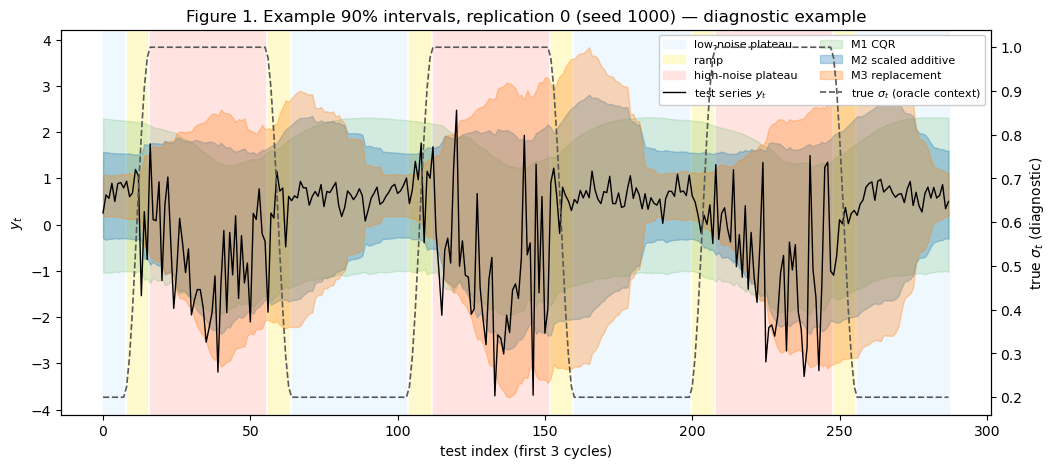

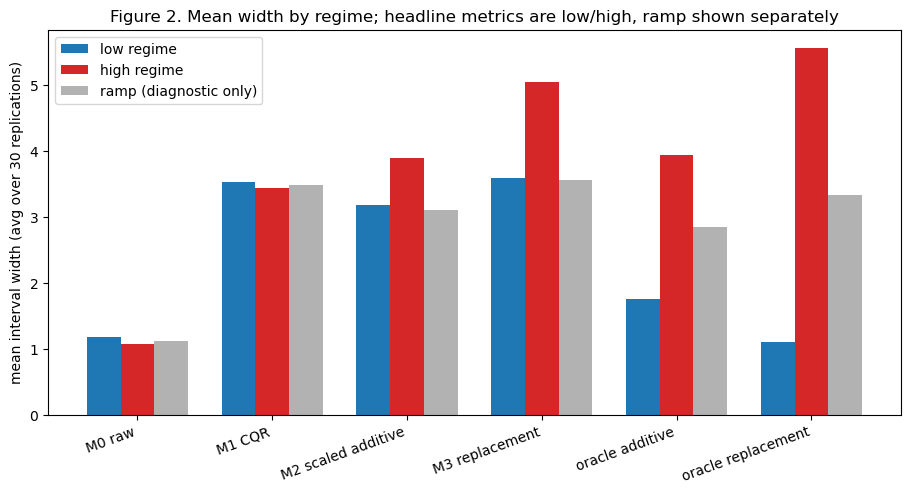

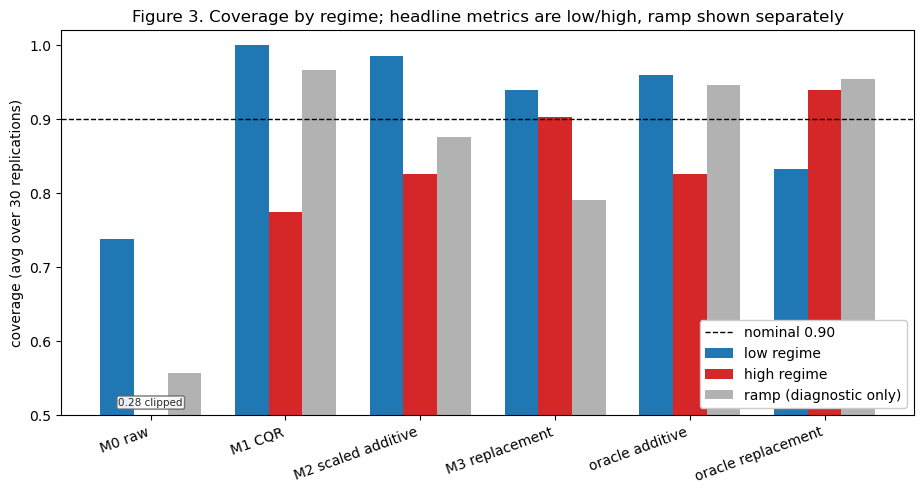

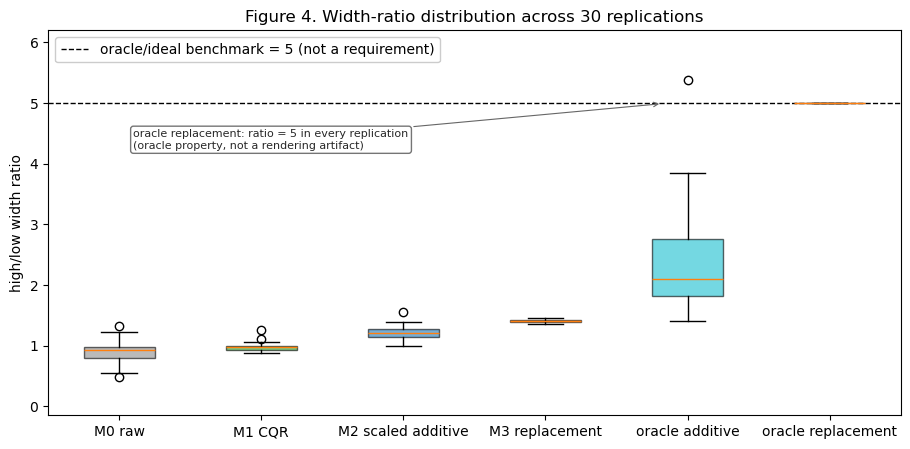

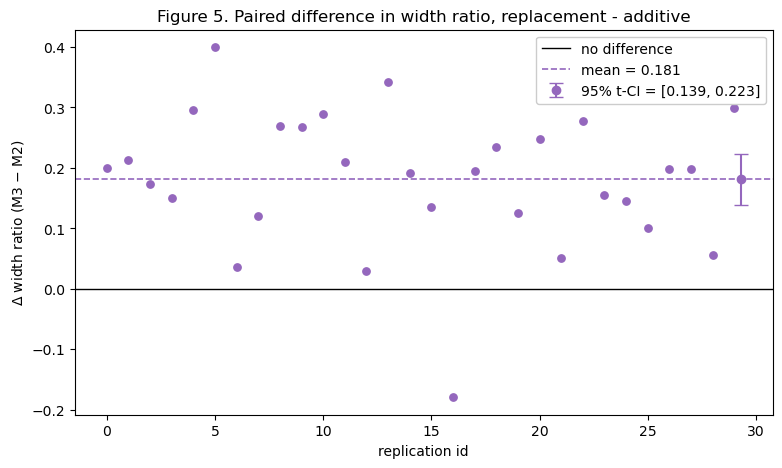

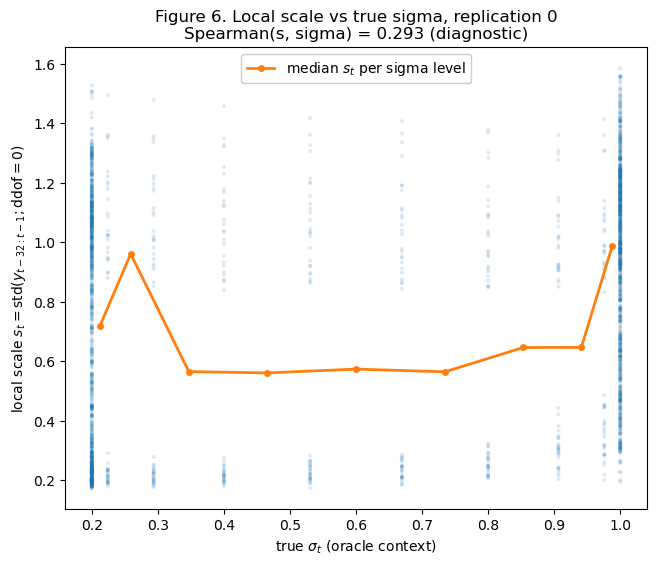

figures written to F:\notebooks\quantile-lstm-conformal-prediction\results\experiment_04\figures


In [11]:
# --- Figures 1-6 (README v1.1, Section 24) ------------------------------
METHOD_COLORS = {
    "M0 Raw Quantile": "0.55",
    "M1 Standard CQR": "tab:green",
    "M2 Scaled Additive CQR": "tab:blue",
    "M3 Replacement CQR": "tab:orange",
    "Oracle Additive CQR": "tab:cyan",
    "Oracle Replacement CQR": "tab:red",
}
SHORT = {"M0 Raw Quantile": "M0 raw", "M1 Standard CQR": "M1 CQR",
         "M2 Scaled Additive CQR": "M2 scaled additive",
         "M3 Replacement CQR": "M3 replacement",
         "Oracle Additive CQR": "oracle additive", "Oracle Replacement CQR": "oracle replacement"}

def savefig(fig, name):
    path = FIGURES_DIR / name
    for attempt in range(4):   # retry transient Windows file locks (AV/indexer)
        try:
            fig.savefig(path, dpi=150, bbox_inches="tight")
            break
        except OSError:
            if attempt == 3:
                raise
            time.sleep(2.0)
    plt.show(); plt.close(fig)

# ---- Figure 1: example test-series interval visualization (replication 0)
lo1, hi1 = example["intervals"]["M1 Standard CQR"]
lo2, hi2 = example["intervals"]["M2 Scaled Additive CQR"]
lo3, hi3 = example["intervals"]["M3 Replacement CQR"]
zoom = slice(0, 288)   # first three test cycles (diagnostic example)
x = np.arange(288)
fig, ax = plt.subplots(figsize=(12, 5))
for regime_val, color, label in [(REGIME_LOW, "aliceblue", "low-noise plateau"),
                                 (REGIME_RAMP, "lemonchiffon", "ramp"),
                                 (REGIME_HIGH, "mistyrose", "high-noise plateau")]:
    in_regime = example["regime"][zoom] == regime_val
    ax.fill_between(x, 0, 1, where=in_regime, transform=ax.get_xaxis_transform(),
                    color=color, zorder=0, label=label)
ax.plot(x, example["y"][zoom], color="k", lw=1.0, label="test series $y_t$")
ax.fill_between(x, lo1[zoom], hi1[zoom], color=METHOD_COLORS["M1 Standard CQR"], alpha=0.15, label=SHORT["M1 Standard CQR"])
ax.fill_between(x, lo2[zoom], hi2[zoom], color=METHOD_COLORS["M2 Scaled Additive CQR"], alpha=0.30, label=SHORT["M2 Scaled Additive CQR"])
ax.fill_between(x, lo3[zoom], hi3[zoom], color=METHOD_COLORS["M3 Replacement CQR"], alpha=0.30, label=SHORT["M3 Replacement CQR"])
ax2 = ax.twinx()
ax2.plot(x, example["sigma"][zoom], color="0.35", ls="--", lw=1.2, label=r"true $\sigma_t$ (oracle context)")
ax2.set_ylabel(r"true $\sigma_t$ (diagnostic)")
ax.set_xlabel("test index (first 3 cycles)")
ax.set_ylabel("$y_t$")
ax.set_title("Figure 1. Example 90% intervals, replication 0 (seed 1000) — diagnostic example")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right", ncol=2, fontsize=8, framealpha=1.0)
savefig(fig, "figure1_example_intervals.png")

# ---- Figure 2: mean width by regime for all methods ---------------------
means = replications.groupby("method")[["low_mean_width", "high_mean_width", "ramp_mean_width_diag"]].mean()
fig, ax = plt.subplots(figsize=(11, 5))
xpos = np.arange(len(METHOD_NAMES))
ax.bar(xpos - 0.25, means["low_mean_width"], 0.25, color="tab:blue", label="low regime")
ax.bar(xpos,        means["high_mean_width"], 0.25, color="tab:red", label="high regime")
ax.bar(xpos + 0.25, means["ramp_mean_width_diag"], 0.25, color="tab:gray", alpha=0.6,
       label="ramp (diagnostic only)")
ax.set_xticks(xpos, [SHORT[m] for m in METHOD_NAMES], rotation=20, ha="right")
ax.set_ylabel("mean interval width (avg over 30 replications)")
ax.set_title("Figure 2. Mean width by regime; headline metrics are low/high, ramp shown separately")
ax.legend()
savefig(fig, "figure2_mean_width_by_regime.png")

# ---- Figure 3: coverage by regime for all methods -----------------------
covs = replications.groupby("method")[["low_coverage", "high_coverage", "ramp_coverage_diag"]].mean()
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(xpos - 0.25, covs["low_coverage"], 0.25, color="tab:blue", label="low regime")
ax.bar(xpos,        covs["high_coverage"], 0.25, color="tab:red", label="high regime")
ax.bar(xpos + 0.25, covs["ramp_coverage_diag"], 0.25, color="tab:gray", alpha=0.6,
       label="ramp (diagnostic only)")
ax.axhline(1 - ALPHA, color="k", ls="--", lw=1, label="nominal 0.90")
ax.set_xticks(xpos, [SHORT[m] for m in METHOD_NAMES], rotation=20, ha="right")
ax.set_ylabel("coverage (avg over 30 replications)")
ax.set_ylim(0.5, 1.02)
ax.set_title("Figure 3. Coverage by regime; headline metrics are low/high, ramp shown separately")
floor = ax.get_ylim()[0]
for dx, col in [(-0.25, "low_coverage"), (0.0, "high_coverage"), (0.25, "ramp_coverage_diag")]:
    for i, m in enumerate(METHOD_NAMES):
        v = float(covs.loc[m, col])
        if v < floor:   # bar clipped by the axis floor: annotate the true value
            ax.text(i + dx, floor + 0.010, f"{v:.2f} clipped", ha="center", va="bottom",
                    fontsize=7.5, color="0.15",
                    bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                              edgecolor="0.4", alpha=0.9))
ax.legend(loc="lower right", framealpha=1.0)
savefig(fig, "figure3_coverage_by_regime.png")

# ---- Figure 4: distribution of width ratios across replications ---------
fig, ax = plt.subplots(figsize=(11, 5))
data_box = [replications.loc[replications["method"] == m, "width_ratio"].to_numpy() for m in METHOD_NAMES]
bp = ax.boxplot(data_box, tick_labels=[SHORT[m] for m in METHOD_NAMES], showfliers=True, patch_artist=True)
for patch, m in zip(bp["boxes"], METHOD_NAMES):
    patch.set_facecolor(METHOD_COLORS[m]); patch.set_alpha(0.6)
ax.axhline(HIGH_SIGMA / LOW_SIGMA, color="k", ls="--", lw=1,
           label="oracle/ideal benchmark = 5 (not a requirement)")
ax.set_ylabel("high/low width ratio")
ax.set_title("Figure 4. Width-ratio distribution across 30 replications")
ax.set_ylim(top=6.2)
ax.annotate("oracle replacement: ratio = 5 in every replication\n(oracle property, not a rendering artifact)",
            xy=(4.82, 4.99), xytext=(1.1, 4.25), ha="left", fontsize=8, color="0.15",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.4", alpha=0.9),
            arrowprops=dict(arrowstyle="->", color="0.4", lw=0.8))
ax.legend(loc="upper left", framealpha=1.0)
savefig(fig, "figure4_width_ratio_distribution.png")

# ---- Figure 5: paired difference in width ratio (replacement - additive) -
wide_ratio = replications.pivot(index="replication", columns="method", values="width_ratio")
delta_ratio = wide_ratio["M3 Replacement CQR"].to_numpy() - wide_ratio["M2 Scaled Additive CQR"].to_numpy()
mean_dr, sd_dr = float(np.mean(delta_ratio)), float(np.std(delta_ratio, ddof=1))
half_dr = T_CRIT_975_DF29 * sd_dr / math.sqrt(N_REPS)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(np.arange(N_REPS), delta_ratio, color="tab:purple", zorder=3, s=28)
ax.axhline(0.0, color="k", lw=1, label="no difference")
ax.axhline(mean_dr, color="tab:purple", ls="--", lw=1.2, label=f"mean = {mean_dr:.3f}")
ax.errorbar(N_REPS - 0.7, mean_dr, yerr=[[half_dr], [half_dr]], fmt="o", color="tab:purple",
            capsize=5, label=f"95% t-CI = [{mean_dr - half_dr:.3f}, {mean_dr + half_dr:.3f}]")
ax.set_xlabel("replication id")
ax.set_ylabel(r"$\Delta$ width ratio (M3 $-$ M2)")
ax.set_title("Figure 5. Paired difference in width ratio, replacement - additive")
ax.legend(framealpha=1.0)
savefig(fig, "figure5_paired_width_ratio_difference.png")

# ---- Figure 6: example local scale versus true sigma (replication 0) ----
fig, ax = plt.subplots(figsize=(7.5, 6))
sp_val = spearman_corr(example["s"], example["sigma"])
ax.scatter(example["sigma"], example["s"], s=8, alpha=0.15, color="tab:blue", edgecolors="none")
bins = np.array([LOW_SIGMA] + [0.6 - 0.4 * np.cos(np.pi * m / 9) for m in range(1, 9)] + [HIGH_SIGMA])
mids, medians = [], []
for a, b in zip(bins[:-1], bins[1:]):
    m = (example["sigma"] >= a) & (example["sigma"] <= b)
    if m.sum() > 5:
        mids.append(0.5 * (a + b)); medians.append(float(np.median(example["s"][m])))
ax.plot(mids, medians, color="tab:orange", lw=2, marker="o", ms=4, label="median $s_t$ per sigma level")
ax.set_xlabel(r"true $\sigma_t$ (oracle context)")
ax.set_ylabel(r"local scale $s_t=\mathrm{std}(y_{t-32:t-1};\mathrm{ddof}{=}0)$")
ax.set_title(f"Figure 6. Local scale vs true sigma, replication 0\n"
             f"Spearman(s, sigma) = {sp_val:.3f} (diagnostic)")
ax.legend(loc="upper center", framealpha=1.0)
savefig(fig, "figure6_local_scale_vs_sigma.png")

print("figures written to", FIGURES_DIR)

## Interpretation guardrails (README v1.1, Sections 20, 25)

**What this experiment can address.** Under the *same* dataset, *same* Quantile LSTM,
*same* local scale estimator, *same* calibration set (D3), and *same* test set, the
paired comparison Replacement (M3) − Scaled Additive (M2) measures whether replacement
geometry adapts interval width across noise regimes differently from additive geometry,
and what each choice costs in coverage.

**Explicit scope separation.**

- **Primary comparison:** M3 − M2 paired differences (coverage, width, width ratio,
  coverage imbalance, Winkler) with paired t-intervals across 30 replications.
- **Oracle diagnostics:** the two ORACLE methods use the true \(\sigma_t\) and bound
  what any local-scale method could achieve with a perfect scale; they are never mixed
  into the primary comparison.
- **Secondary diagnostics:** ramp-regime values, D2 out-of-fold checks, raw quantile
  crossing fraction, and Spearman(\(s_t, \sigma_t\)). Spearman association is a
  property of the *frozen* scale estimator, not evidence about interval geometry, and
  correlation(width, scale) is explicitly **not** treated as evidence of adaptivity.
- **Temporal-calibration caveat:** the data are dependent time-series observations.
  Ordinary iid split-conformal finite-sample validity is **not** claimed; no
  theorem-level guarantee is asserted for these chronological intervals. The
  chronological protocol is an empirical time-series evaluation. Block-based or
  time-series-aware calibration is deliberately out of scope and deferred to a future
  Experiment 05 (README v1.1, Section 20).

**Interpretation rules.** No claim that replacement CQR is better is made or implied by
this notebook; results speak for themselves. If replacement improves width adaptation
but hurts coverage, both facts are reported. If additive performs equally well, that is
reported. If the hypothesis fails, the experiment is still scientifically useful. The
oracle/ideal width-ratio benchmark of 5 was never used as a tuning objective; no
hyperparameter, DGP, scale estimator, calibration rule, or metric was changed after
observing any result.

In [12]:
# --- finalize: frozen configuration + seeds in output metadata -----------
import datetime

output_record = {
    "spec": FROZEN_CONFIG["spec"],
    "notebook": "experiments/04_controlled_comparison_replacement_vs_additive.ipynb",
    "frozen_config": FROZEN_CONFIG,
    "replication_seeds": REPLICATION_SEEDS,
    "environment": ENVIRONMENT,
    "executed_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
    "total_wall_time_s": round(time.perf_counter() - t_exp, 1),
    "outputs": {
        "replication_results": str(RESULTS_DIR / "replication_results.csv"),
        "summary_results": str(RESULTS_DIR / "summary_results.csv"),
        "paired_comparisons": str(RESULTS_DIR / "paired_comparisons.csv"),
        "figures": sorted(p.name for p in FIGURES_DIR.glob("*.png")),
    },
    "protocol_notes": [
        "no hyperparameter was tuned after observing results",
        "no primary method was altered after observing test results",
        "no theorem-level iid split-conformal validity is claimed (chronological time-series protocol)",
    ],
}
with open(RESULTS_DIR / "config.json", "w", encoding="utf-8") as fh:
    json.dump(output_record, fh, indent=2)

print("Experiment 04 execution complete (results frozen; no tuning performed).")
print("\nOutput files:")
for p in sorted(RESULTS_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(REPO_ROOT)}  ({p.stat().st_size:,} bytes)")

Experiment 04 execution complete (results frozen; no tuning performed).

Output files:
  results\experiment_04\config.json  (4,065 bytes)
  results\experiment_04\figures\figure1_example_intervals.png  (273,516 bytes)
  results\experiment_04\figures\figure2_mean_width_by_regime.png  (77,376 bytes)
  results\experiment_04\figures\figure3_coverage_by_regime.png  (86,158 bytes)
  results\experiment_04\figures\figure4_width_ratio_distribution.png  (61,479 bytes)
  results\experiment_04\figures\figure5_paired_width_ratio_difference.png  (52,088 bytes)
  results\experiment_04\figures\figure6_local_scale_vs_sigma.png  (110,442 bytes)
  results\experiment_04\paired_comparisons.csv  (836 bytes)
  results\experiment_04\replication_results.csv  (82,523 bytes)
  results\experiment_04\summary_results.csv  (9,437 bytes)
